# Task 3: Inverse NN to predict permeability using velocity and coordinates

### 0. Importing libraries

In [78]:
%pip install -q numpy pandas matplotlib scipy openpyxl torch

Note: you may need to restart the kernel to use updated packages.


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import random

In [80]:
# Set the same random seed for reproducible runs.
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

In [81]:
# Prefer CUDA, then Apple Metal (MPS), and otherwise use the CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cpu


### 1. Importing dataset

Text(0.5, 1.0, 'Scatter Plot of Water Dam Data')

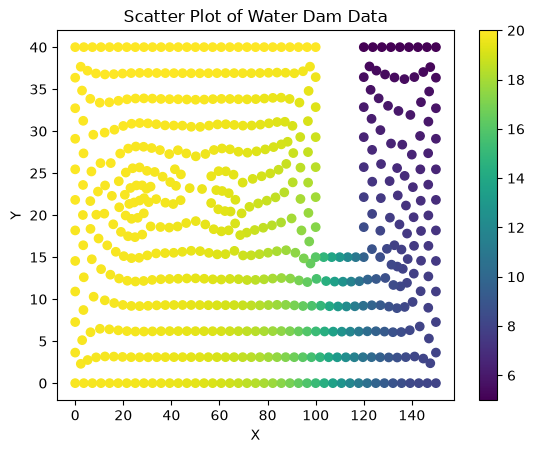

In [82]:
numericldata = pd.read_excel('../Data/heads/20_5_25.xlsx',header=0)
X = numericldata['X'].to_numpy()
Y = numericldata['Y'].to_numpy()
h = numericldata['FINIT'].to_numpy()

fig, ax = plt.subplots()

scatter = ax.scatter(X, Y, c=h, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot of Water Dam Data')

Text(0.5, 1.0, 'Scatter Plot of velocities of Water Dam Data')

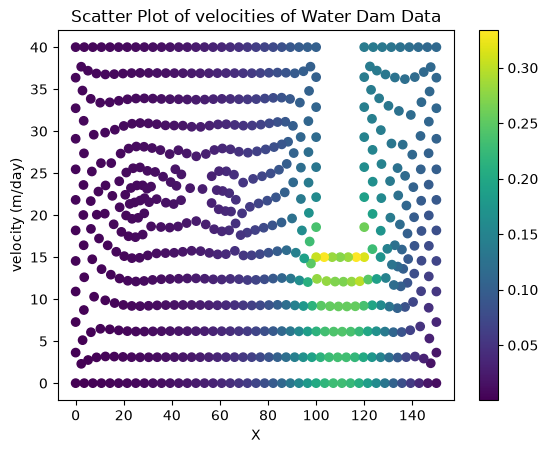

In [83]:
numeric_vel_ldata = pd.read_excel('../Data/velocities/20_5_25.xlsx',header=0)
v = numeric_vel_ldata['VINIT'].to_numpy()
X = numeric_vel_ldata['X'].to_numpy()
Y = numeric_vel_ldata['Y'].to_numpy()

fig, ax = plt.subplots()

scatter = ax.scatter(X, Y, c=v, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('velocity (m/day)')
ax.set_title('Scatter Plot of velocities of Water Dam Data')

### 2. Normalizing variables

#### Setting up default variables

In [84]:
# Geometry of problem
h1 = 20
h2 = 5
hd = 25

L = 150

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = L   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - hd    # bottom of dam


In [85]:
def interpolate_head(X, Y, h, 
                     grid_res=(300, 100),
                     domain_bounds=(x_left, x_right, y_bot, y_top),
                     dam_bounds=(x_dleft, x_dright, y_dbot, y_top),
                     method="linear"):
    
    x_min, x_max, y_min, y_max = domain_bounds
    num_x, num_y = grid_res

    # Generate regular 2D grid
    xi = np.linspace(x_min, x_max, num_x)
    yi = np.linspace(y_min, y_max, num_y)
    grid_x, grid_y = np.meshgrid(xi, yi)

    # Interpolate scattered points
    grid_h = griddata((X,Y), h, (grid_x, grid_y), method=method)

    # Mask out dam region
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    # Replace all h values within the dam area with nan
    grid_h[dam_mask] = np.nan

    return grid_x, grid_y, grid_h

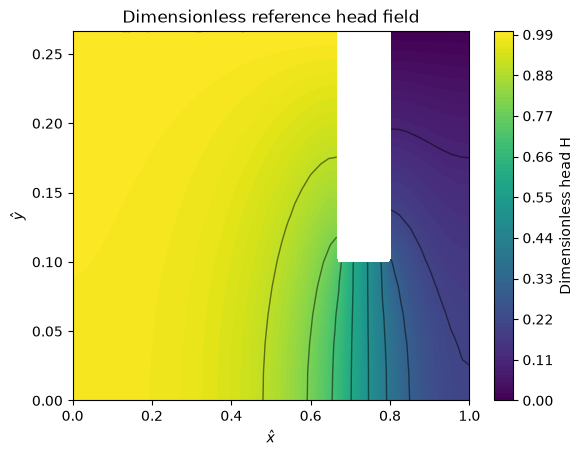

In [86]:
grid_X, grid_Y, grid_h = interpolate_head(X, Y, h)
def to_hat_xy(xy):
    """Convert dimensional coordinates [m] to nondimensional coordinates."""
    return xy / L

def to_hat_head(h):
    return (h-h2)/(h1-h2)

def from_hat_head(H):
    """Convert nondimensional head H back to dimensional head h [m]."""
    return h2 + (h1 - h2) * H

grid_X_hat, grid_Y_hat, grid_h_hat = to_hat_xy(grid_X), to_hat_xy(grid_Y), to_hat_head(grid_h)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X_hat, grid_Y_hat, grid_h_hat, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Dimensionless head H')
ax.contour(grid_X_hat, grid_Y_hat, grid_h_hat, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel(r'$\hat{x}$')
ax.set_ylabel(r'$\hat{y}$')
ax.set_title('Dimensionless reference head field')
plt.show()

### 3. Setting up boundary conditions for loss function

In [87]:
# normalise domain and dam bounds
# xmin, xmax, ymin, ymax
domain_bounds = np.array([x_left, x_right, y_bot, y_top])
dam_bounds = np.array([x_dleft, x_dright, y_dbot, y_top])

domain_bounds_norm = to_hat_xy(domain_bounds)
dam_bounds_norm = to_hat_xy(dam_bounds)

print(domain_bounds_norm)
print(dam_bounds_norm)

[0.         1.         0.         0.26666667]
[0.66666667 0.8        0.1        0.26666667]


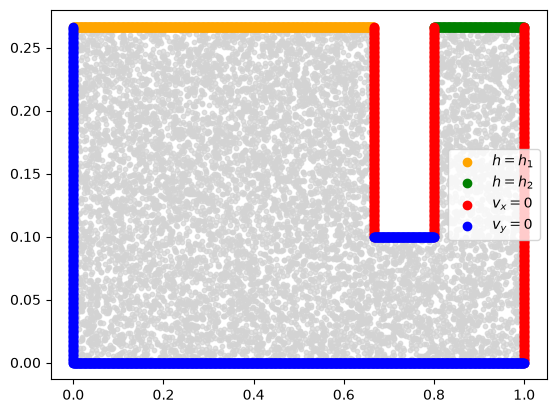

In [88]:

def sample_boundaries(n_density, domain_bounds, dam_bounds):

    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds


    x1 = np.linspace(x_l, x_dl, int(n_density * (x_dl-x_l)))
    y1 = np.ones(int(n_density * (x_dl-x_l))) * y_t
    h1 = np.column_stack([x1, y1])

    x2 = np.linspace(x_dr, x_r, int(n_density*(x_r-x_dr)))
    y2 = np.ones(int(n_density*(x_r-x_dr))) * y_t
    h2 = np.column_stack([x2, y2])


    x3 = np.ones(int(n_density*(y_t-y_db))) * x_dl
    y3 = np.linspace(y_db, y_t, int(n_density*(y_t-y_db)))

    x4 = np.ones(int(n_density*(y_t-y_db))) * x_dr
    y4 = np.linspace(y_db, y_t, int(n_density*(y_t-y_db)))

    x7 = np.ones(int(n_density*(y_t))) * x_r
    y7 = np.linspace(y_b, y_t, int(n_density*(y_t)))
    vx0 = np.column_stack([
        np.concatenate([x3, x4, x7]),
        np.concatenate([y3, y4, y7])
    ])

    y5 = np.ones(int(n_density*(x_dr-x_dl))) * y_db
    x5 = np.linspace(x_dl, x_dr, int(n_density*(x_dr-x_dl)))

    y6 = np.zeros(int(n_density*(x_r)))
    x6 = np.linspace(x_l, x_r, int(n_density*(x_r)))

    x8 = np.ones(int(n_density*(y_t))) * x_l
    y8 = np.linspace(y_b, y_t, int(n_density*(y_t)))
    vy0 = np.column_stack([
        np.concatenate([x5, x6, x8]),
        np.concatenate([y5, y6, y8])
    ])

    return {
        "h1": h1,
        "h2": h2,
        "vx0": vx0,
        "vy0": vy0,
    }

def sample_interior_points(num_points, domain_bounds, dam_bounds):
    
    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds

    sampled_x = []
    sampled_y = []
    
    while len(sampled_x) < num_points:
        # 1. Generate a random candidate point inside the global bounding box
        x_candidate = np.random.uniform(x_l, x_r)
        y_candidate = np.random.uniform(y_b, y_t)
        
        # 2. Check if the point falls inside the forbidden dam cutout zone
        is_inside_dam = (x_dl <= x_candidate <= x_dr) and (y_db <= y_candidate <= y_t)
        
        # 3. Only keep the point if it is NOT inside the dam
        if not is_inside_dam:
            sampled_x.append(x_candidate)
            sampled_y.append(y_candidate)
            
    return np.column_stack([np.array(sampled_x), np.array(sampled_y)])

# Sample boundary points
bc_density = 1000
bc = sample_boundaries(bc_density, domain_bounds_norm, dam_bounds_norm)


x_bc_h1, y_bc_h1 = bc['h1'][:, 0].reshape(-1, 1), bc['h1'][:, 1].reshape(-1, 1)
x_bc_h2, y_bc_h2 = bc['h2'][:, 0].reshape(-1, 1), bc['h2'][:, 1].reshape(-1, 1)
x_bc_vx0, y_bc_vx0 = bc["vx0"][:, 0].reshape(-1, 1), bc["vx0"][:, 1].reshape(-1, 1)
x_bc_vy0, y_bc_vy0 = bc["vy0"][:, 0].reshape(-1, 1), bc["vy0"][:, 1].reshape(-1, 1)



h1_color = "orange"
h2_color = "green"
vx0_color = "red"
vy0_color = "blue"


plt.scatter(x_bc_h1, y_bc_h1, color=h1_color, label="$h=h_1$")
plt.scatter(x_bc_h2, y_bc_h2, color=h2_color, label="$h=h_2$")
plt.scatter(x_bc_vx0, y_bc_vx0, color=vx0_color, label="$v_x=0$")
plt.scatter(x_bc_vy0, y_bc_vy0, color=vy0_color, label="$v_y=0$")
plt.legend()


# Sample interior points
n_points = 10000
xy_internal = sample_interior_points(n_points, domain_bounds_norm, dam_bounds_norm)
x_internal, y_internal = xy_internal[:,0].reshape(-1, 1), xy_internal[:,1].reshape(-1, 1)



plt.scatter(xy_internal[:,0], xy_internal[:,1], color='lightgray', s=10, label='Interior Sampled Points', alpha=0.7, zorder=-2)


plt.show()





Define PINN Loss functions

Our model receives non-dimensional coordinates and predicts non-dimensional head:

$$
(\hat{x}, \hat{y}) \mapsto H_\theta(\hat{x}, \hat{y}).
$$

We have two types of loss: boundary condition loss and PDE loss. Each boundary type has its own loss:





In [89]:
# when head must have a specfic numerical value at boundary
def loss_bc_value(model, x, y, val):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)

    bc_real = torch.full_like(H, val, device=device)
    bc_loss = torch.mean((H - bc_real)**2)
    return bc_loss

# when one of the derivatives must vanish
# dim = 0 or 1 (x or y)
def loss_bc_grad(model, x, y, dim):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    
    u = x if dim==0 else y
    H_u = torch.autograd.grad(H, u,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    
    # derivative should vanish, so nonzero value is taken as loss
    bc_loss = torch.mean((H_u)**2)
    return bc_loss

# PDE loss, from LaPlace equation
def loss_pde(model, x, y):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    H_x = torch.autograd.grad(H, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_xx = torch.autograd.grad(H_x, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_y = torch.autograd.grad(H, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_yy = torch.autograd.grad(H_y, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]

    pde_residual = H_xx + H_yy
    return torch.mean(pde_residual**2)


# when y derivative of head must vanish



### 4. Loss Function

 Fixed-weight PINN loss and training

The network maps nondimensional coordinates to nondimensional head:

$$ (\hat{x},\hat{y}) \mapsto H_\theta(\hat{x},\hat{y}). $$

The grouped loss is

$$ \mathcal{L}=\mathcal{L}_{PDE}+\lambda_D\mathcal{L}_D+\lambda_N\mathcal{L}_N, $$

where

$$ \mathcal{L}_{PDE}=\operatorname{MSE}(H_{,\hat{x}\hat{x}}+H_{,\hat{y}\hat{y}},0), $$

$$ \mathcal{L}_D=\operatorname{MSE}(H,1)_{reservoir}+\operatorname{MSE}(H,0)_{catchment}, $$

$$ \mathcal{L}_N=\operatorname{MSE}(H_{,\hat{x}},0)_{vertical}+\operatorname{MSE}(H_{,\hat{y}},0)_{horizontal}. $$


### Defining ML model

In [90]:
class MLP(nn.Module):
    # arch = [inputs] + [hidden neurons]*number + [outputs]
    def __init__(self, arch, act):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(arch) - 1):
            layers.append(nn.Linear(arch[i], arch[i + 1]))
            if i < len(arch) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        out = self.model(inputs)
        return out

Epoch 0: Loss = 2.1680e+01, PDE Loss = 1.8606e-04, BC h1 Loss = 1.0817e+00, BC h2 Loss 2.1052e-03, BC vx0 Loss 6.126996595412493e-05, BC vy0 Loss 0.0005239021847955883
Epoch 100: Loss = 5.9831e+00, PDE Loss = 8.2604e-02, BC h1 Loss = 1.1449e-01, BC h2 Loss 9.0494e-02, BC vx0 Loss 0.35948532819747925, BC vy0 Loss 0.0006786072626709938
Epoch 200: Loss = 5.3213e+00, PDE Loss = 1.1349e-01, BC h1 Loss = 1.1999e-01, BC h2 Loss 7.6052e-02, BC vx0 Loss 0.2404378205537796, BC vy0 Loss 0.016975294798612595
Epoch 300: Loss = 4.9765e+00, PDE Loss = 9.3354e-02, BC h1 Loss = 1.3731e-01, BC h2 Loss 5.2558e-02, BC vx0 Loss 0.2018120139837265, BC vy0 Loss 0.015332341194152832
Epoch 400: Loss = 4.7303e+00, PDE Loss = 4.0791e-02, BC h1 Loss = 1.0537e-01, BC h2 Loss 6.7768e-02, BC vx0 Loss 0.23219794034957886, BC vy0 Loss 0.013153876177966595


Text(0.5, 0, 'Epoch')

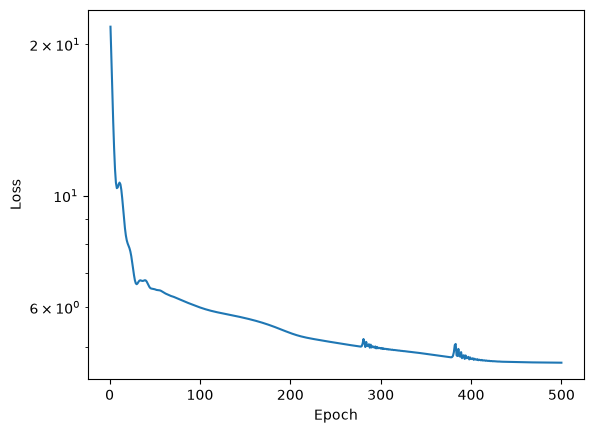

In [96]:
# Create neural network with tanh activation function
layers = [2] + [50]*4 + [1]
model = MLP(layers, nn.Tanh).to(device)
# Save the common initialization for a fair fixed/adaptive comparison.
initial_model_state = {
    name: value.detach().clone() for name, value in model.state_dict().items()
}

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Number of epochs
num_epochs = 500

lambda_D = 20.0
lambda_N = 5.0

history_fixed = {
    "total": [], "pde": [], "dirichlet": [], "neumann": [],
    "bc_h1": [], "bc_h2": [], "bc_vx0": [], "bc_vy0": [],
}

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    # Compute losses
    bc_h1_loss = loss_bc_value(model, bc['h1'][:,0].reshape(-1, 1), bc['h1'][:,1].reshape(-1, 1), 1)
    bc_h2_loss = loss_bc_value(model, bc['h2'][:,0].reshape(-1, 1), bc['h2'][:,1].reshape(-1, 1), 0)
    bc_vx0_loss = loss_bc_grad(model, bc['vx0'][:,0].reshape(-1, 1), bc['vx0'][:,1].reshape(-1, 1), dim=0)
    bc_vy0_loss = loss_bc_grad(model, bc['vy0'][:,0].reshape(-1, 1), bc['vy0'][:,1].reshape(-1, 1), dim=1)
    pde_loss = loss_pde(model, x_internal, y_internal)

    dirichlet_loss = bc_h1_loss + bc_h2_loss
    neumann_loss = bc_vx0_loss + bc_vy0_loss
    loss = pde_loss + lambda_D * dirichlet_loss + lambda_N * neumann_loss
    loss.backward()
    optimizer.step()

    history_fixed["total"].append(loss.item())
    history_fixed["pde"].append(pde_loss.item())
    history_fixed["dirichlet"].append(dirichlet_loss.item())
    history_fixed["neumann"].append(neumann_loss.item())
    history_fixed["bc_h1"].append(bc_h1_loss.item())
    history_fixed["bc_h2"].append(bc_h2_loss.item())
    history_fixed["bc_vx0"].append(bc_vx0_loss.item())
    history_fixed["bc_vy0"].append(bc_vy0_loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4e}, PDE Loss = {pde_loss.item():.4e}, BC h1 Loss = {bc_h1_loss.item():.4e}, BC h2 Loss {bc_h2_loss.item():.4e}, BC vx0 Loss {bc_vx0_loss}, BC vy0 Loss {bc_vy0_loss}")


# Keep a stable reference before creating the adaptive model.
model_fixed = model

epochs = np.arange(1, len(history_fixed["total"]) + 1)
plt.semilogy(epochs, history_fixed["total"])
plt.ylabel("Loss")
plt.xlabel("Epoch")

In [94]:
def predict_head_grid(model, nx=300, ny=100):
    """Evaluate dimensionless H on the aquifer grid and return dimensional h."""
    x_grid = np.linspace(x_left, x_right, nx)
    y_grid = np.linspace(y_bot, y_top, ny)
    x_mesh, y_mesh = np.meshgrid(x_grid, y_grid, indexing="xy")
    xy_dim = np.column_stack([x_mesh.ravel(), y_mesh.ravel()])
    xy_hat = to_hat_xy(xy_dim)

    model.eval()
    with torch.no_grad():
        H_pred = model(torch.as_tensor(xy_hat, dtype=torch.float32, device=device))

    H_pred = H_pred.detach().cpu().numpy().reshape(y_mesh.shape)
    h_pred = from_hat_head(H_pred)
    dam_mask = ((x_mesh >= x_dleft) & (x_mesh <= x_dright) &
                (y_mesh >= y_dbot) & (y_mesh <= y_top))
    return x_mesh, y_mesh, np.ma.masked_where(dam_mask, h_pred)

def plot_head_prediction(model, title, nx=300, ny=100):
    """Plot predicted dimensional head on physical coordinates."""
    x_mesh, y_mesh, h_pred = predict_head_grid(model, nx=nx, ny=ny)

    fig, ax = plt.subplots(figsize=(10, 4))
    levels = np.linspace(h2, h1, 101)
    contour = ax.contourf(
        x_mesh, y_mesh, h_pred, levels=levels, cmap="viridis", extend="both"
    )
    ax.contour(
        x_mesh, y_mesh, h_pred, levels=np.linspace(h2, h1, 11),
        colors="white", linewidths=0.6, alpha=0.55
    )
    ax.fill(
        [x_dleft, x_dright, x_dright, x_dleft],
        [y_dbot, y_dbot, y_top, y_top],
        color="0.6", label="impermeable dam"
    )

    
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label("Predicted hydraulic head h [m]")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bot, y_top)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()
    return fig, ax, h_pred



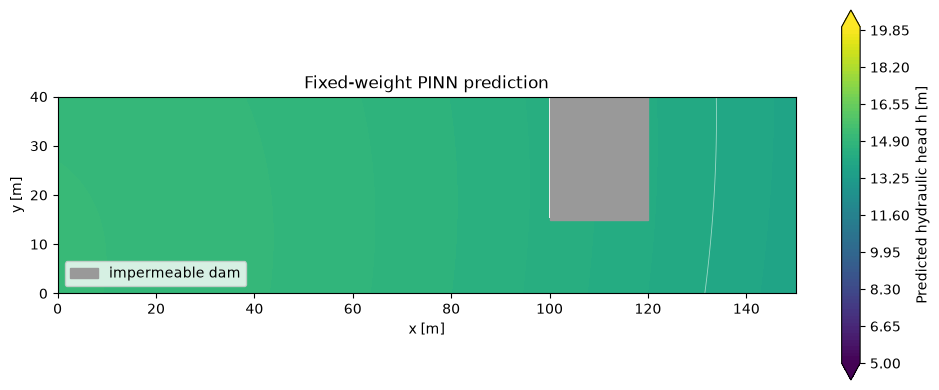

(<Figure size 1000x400 with 2 Axes>,
 <Axes: title={'center': 'Fixed-weight PINN prediction'}, xlabel='x [m]', ylabel='y [m]'>,
 masked_array(
   data=[[15.068516731262207, 15.067749977111816, 15.066957473754883, ...,
          13.764476776123047, 13.757539749145508, 13.750593185424805],
         [15.068683624267578, 15.067919731140137, 15.067129135131836, ...,
          13.765226364135742, 13.758289337158203, 13.751346588134766],
         [15.068836212158203, 15.068076133728027, 15.06728744506836, ...,
          13.765968322753906, 13.759035110473633, 13.752091407775879],
         ...,
         [15.020880699157715, 15.020356178283691, 15.019800186157227, ...,
          13.805155754089355, 13.798538208007812, 13.791912078857422],
         [15.019710540771484, 15.019187927246094, 15.018637657165527, ...,
          13.805224418640137, 13.79861068725586, 13.791988372802734],
         [15.018527030944824, 15.018007278442383, 15.017459869384766, ...,
          13.805285453796387, 13.7986764

In [95]:
# Fixed-weight baseline prediction (before adaptive-weight retraining).
plot_head_prediction(model, "Fixed-weight PINN prediction")

### 7. Train Neural Network using variable-weights

In [92]:
#calc velocitty
k = np.random.rand()
def calc_vel(h):
    synth_H_x = torch.autograd.grad(h, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]

    synth_H_y = torch.autograd.grad(h, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    
    v = k* np.sqrt(synth_H_x^2+synth_H_y^2) 
    return v


In [93]:
ds_v_loss = np.mean(v_ds - calc_vel(h_pred))

NameError: name 'v_ds' is not defined